In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully")

Libraries loaded successfully


In [4]:
master_df = pd.read_csv(
    "../data/processed/featured_dataset.csv"
)

master_df['DATE_TIME'] = pd.to_datetime(
    master_df['DATE_TIME']
)

print("Dataset loaded successfully")

display(master_df.head())

Dataset loaded successfully


,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,HOUR,DAY,MONTH,DAY_OF_WEEK,WEEK_OF_YEAR,IS_PEAK_HOUR,TEMP_DIFFERENCE,IRRADIATION_EFFICIENCY,PREVIOUS_AC_POWER,ROLLING_MEAN_AC_POWER
0,2020-05-15,4136001,LYwnQax7tkwH5Cb,0.0,0.0,1872.500000,1.794959e+09,27.004764,25.060789,0.0,0,15,5,4,20,0,-1.943975,0.0,0.0,0.0
1,2020-05-15,4136001,LlT2YUhhzqhg5Sw,0.0,0.0,1094.357143,2.825928e+08,27.004764,25.060789,0.0,0,15,5,4,20,0,-1.943975,0.0,0.0,0.0
2,2020-05-15,4136001,Mx2yZCDsyf6DPfv,0.0,0.0,5692.200000,2.453646e+06,27.004764,25.060789,0.0,0,15,5,4,20,0,-1.943975,0.0,0.0,0.0
3,2020-05-15,4136001,NgDl19wMapZy17u,0.0,0.0,1866.200000,1.115126e+08,27.004764,25.060789,0.0,0,15,5,4,20,0,-1.943975,0.0,0.0,0.0
4,2020-05-15,4136001,PeE6FRyGXUgsRhN,0.0,0.0,651.200000,1.348351e+09,27.004764,25.060789,0.0,0,15,5,4,20,0,-1.943975,0.0,0.0,0.0


In [5]:
features_df = master_df.drop(
    columns=[
        'DATE_TIME',
        'SOURCE_KEY',
        'AC_POWER',
        'DC_POWER'
    ]
)

target = master_df['AC_POWER']

print("Features prepared successfully")

print(features_df.columns)

Features prepared successfully
Index(['PLANT_ID', 'DAILY_YIELD', 'TOTAL_YIELD', 'AMBIENT_TEMPERATURE',
       'MODULE_TEMPERATURE', 'IRRADIATION', 'HOUR', 'DAY', 'MONTH',
       'DAY_OF_WEEK', 'WEEK_OF_YEAR', 'IS_PEAK_HOUR', 'TEMP_DIFFERENCE',
       'IRRADIATION_EFFICIENCY', 'PREVIOUS_AC_POWER', 'ROLLING_MEAN_AC_POWER'],
      dtype='str')


In [6]:
split_index = int(len(features_df) * 0.8)

X_train = features_df.iloc[:split_index]

X_test = features_df.iloc[split_index:]

y_train = target.iloc[:split_index]

y_test = target.iloc[split_index:]

print("Training Shape:", X_train.shape)

print("Testing Shape:", X_test.shape)

Training Shape: (109175, 16)
Testing Shape: (27294, 16)


In [7]:
def evaluate_model(
    model_name,
    y_true,
    y_pred
):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    mse = mean_squared_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_true,
        y_pred
    )

    return {
        'Model': model_name,
        'MAE': mae,
        'RMSE': rmse,
        'R2 Score': r2
    }

In [8]:
param_grid_rf = {

    'n_estimators': [50,100,200,300],

    'max_depth': [5,10,15,20,None],

    'min_samples_split': [2,5,10],

    'min_samples_leaf': [1,2,4],

    'max_features': ['sqrt','log2']
}

In [9]:
rf_random = RandomizedSearchCV(

    estimator=RandomForestRegressor(
        random_state=42
    ),

    param_distributions=param_grid_rf,

    n_iter=5,

    cv=3,

    verbose=2,

    random_state=42,

    n_jobs=-1
)

rf_random.fit(
    X_train,
    y_train
)

print("Best Random Forest Parameters:")

print(rf_random.best_params_)

Fitting 3 folds for each of 5 candidates, totalling 15 fits


Best Random Forest Parameters:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}


In [10]:
best_rf_model = rf_random.best_estimator_

rf_predictions = best_rf_model.predict(
    X_test
)

rf_results = evaluate_model(
    "Tuned Random Forest",
    y_test,
    rf_predictions
)

print(rf_results)

{'Model': 'Tuned Random Forest', 'MAE': 7.616376186084376, 'RMSE': np.float64(18.33753904807056), 'R2 Score': 0.9968867598905075}


In [11]:
param_grid_xgb = {

    'n_estimators': [50,100,200],

    'max_depth': [3,5,7,10],

    'learning_rate': [0.01,0.05,0.1,0.2],

    'subsample': [0.7,0.8,1.0],

    'colsample_bytree': [0.7,0.8,1.0]
}

In [12]:
xgb_random = RandomizedSearchCV(

    estimator=XGBRegressor(
        random_state=42
    ),

    param_distributions=param_grid_xgb,

    n_iter=5,

    cv=3,

    verbose=2,

    random_state=42,

    n_jobs=-1
)

xgb_random.fit(
    X_train,
    y_train
)

print("Best XGBoost Parameters:")

print(xgb_random.best_params_)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best XGBoost Parameters:
{'subsample': 1.0, 'n_estimators': 100, 'max_depth': 10, 'learning_rate': 0.1, 'colsample_bytree': 1.0}


In [13]:
best_xgb_model = xgb_random.best_estimator_

xgb_predictions = best_xgb_model.predict(
    X_test
)

xgb_results = evaluate_model(
    "Tuned XGBoost",
    y_test,
    xgb_predictions
)

print(xgb_results)

{'Model': 'Tuned XGBoost', 'MAE': 2.169628120914815, 'RMSE': np.float64(7.182540140972457), 'R2 Score': 0.9995223754545483}


In [14]:
param_grid_dt = {

    'max_depth': [3,5,10,15,20,None],

    'min_samples_split': [2,5,10,20],

    'min_samples_leaf': [1,2,4,8],

    'criterion': ['squared_error','friedman_mse']
}

In [15]:
dt_random = RandomizedSearchCV(

    estimator=DecisionTreeRegressor(
        random_state=42
    ),

    param_distributions=param_grid_dt,

    n_iter=5,

    cv=3,

    verbose=2,

    random_state=42,

    n_jobs=-1
)

dt_random.fit(
    X_train,
    y_train
)

print("Best Decision Tree Parameters:")

print(dt_random.best_params_)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best Decision Tree Parameters:
{'min_samples_split': 2, 'min_samples_leaf': 8, 'max_depth': 20, 'criterion': 'squared_error'}


In [16]:
best_dt_model = dt_random.best_estimator_

dt_predictions = best_dt_model.predict(
    X_test
)

dt_results = evaluate_model(
    "Tuned Decision Tree",
    y_test,
    dt_predictions
)

print(dt_results)

{'Model': 'Tuned Decision Tree', 'MAE': 3.1200181449692375, 'RMSE': np.float64(11.239781144536224), 'R2 Score': 0.9988303761279438}


In [17]:
tuned_results_df = pd.DataFrame([
    rf_results,
    xgb_results,
    dt_results
])

tuned_results_df = tuned_results_df.sort_values(
    by='R2 Score',
    ascending=False
)

display(tuned_results_df)

,Model,MAE,RMSE,R2 Score
1,Tuned XGBoost,2.169628,7.182540,0.999522
2,Tuned Decision Tree,3.120018,11.239781,0.998830
0,Tuned Random Forest,7.616376,18.337539,0.996887


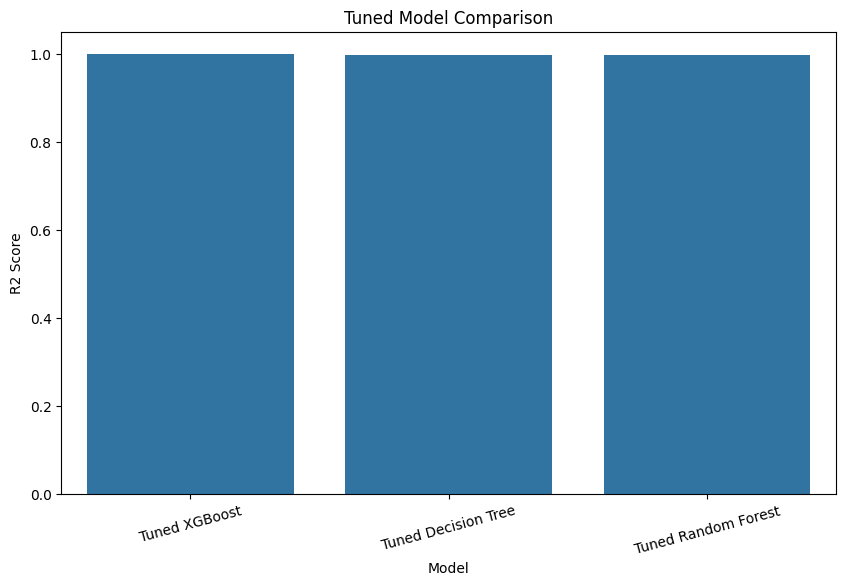

In [18]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Model',
    y='R2 Score',
    data=tuned_results_df
)

plt.title("Tuned Model Comparison")

plt.xticks(rotation=15)

plt.show()

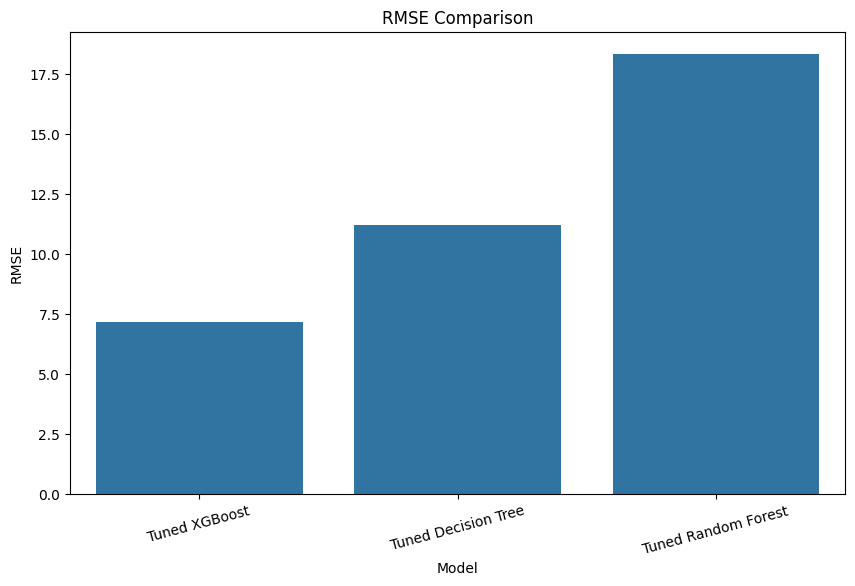

In [19]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Model',
    y='RMSE',
    data=tuned_results_df
)

plt.title("RMSE Comparison")

plt.xticks(rotation=15)

plt.show()

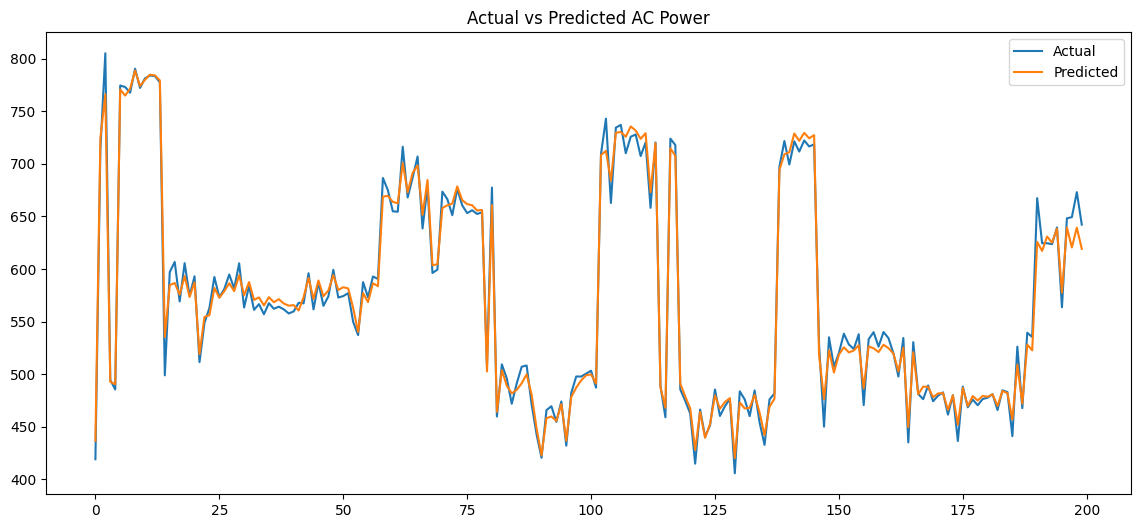

In [20]:
plt.figure(figsize=(14,6))

plt.plot(
    y_test.values[:200],
    label='Actual'
)

plt.plot(
    rf_predictions[:200],
    label='Predicted'
)

plt.title("Actual vs Predicted AC Power")

plt.legend()

plt.show()

In [21]:
import joblib

In [22]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(
    best_rf_model,
    "../models/random_forest_model.pkl"
)

print("Random Forest model saved successfully")

Random Forest model saved successfully


In [23]:
joblib.dump(
    best_xgb_model,
    "../models/xgboost_model.pkl"
)

['../models/xgboost_model.pkl']

In [24]:
joblib.dump(
    best_dt_model,
    "../models/decision_tree_model.pkl"
)

['../models/decision_tree_model.pkl']

In [25]:
import pandas as pd
import plotly.express as px

In [26]:
rf_results = pd.DataFrame(
    rf_random.cv_results_
)

rf_results.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_estimators,param_min_samples_split,param_min_samples_leaf,param_max_features,param_max_depth,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,12.398434,2.757985,0.425018,0.121601,50,10,1,sqrt,20,"{'n_estimators': 50, 'min_samples_split': 10, ...",0.997488,0.995959,0.995230,0.996226,0.000941,2
1,23.889918,0.288570,0.580520,0.020022,200,5,1,log2,5,"{'n_estimators': 200, 'min_samples_split': 5, ...",0.970189,0.975737,0.969040,0.971655,0.002924,4
2,23.959171,2.565124,0.611107,0.082754,100,10,4,log2,20,"{'n_estimators': 100, 'min_samples_split': 10,...",0.997310,0.996307,0.994934,0.996184,0.000974,3
3,44.798466,1.855634,1.269800,0.102027,200,2,2,sqrt,None,"{'n_estimators': 200, 'min_samples_split': 2, ...",0.997600,0.996634,0.995391,0.996542,0.000904,1
4,4.388195,1.242893,0.131608,0.051037,50,10,2,log2,5,"{'n_estimators': 50, 'min_samples_split': 10, ...",0.969348,0.972746,0.969259,0.970451,0.001623,5


In [27]:
fig = px.line(

    rf_results,

    x='param_n_estimators',

    y='mean_test_score',

    title='Random Forest: n_estimators vs Mean CV Score',

    markers=True
)

fig.show()

In [28]:
fig = px.line(

    rf_results,

    x='param_max_depth',

    y='mean_test_score',

    title='Random Forest: max_depth vs Mean CV Score',

    markers=True
)

fig.show()

In [29]:
fig = px.box(

    rf_results,

    x='param_min_samples_split',

    y='mean_test_score',

    title='Random Forest: min_samples_split vs CV Score'
)

fig.show()

In [30]:
xgb_results = pd.DataFrame(
    xgb_random.cv_results_
)

display(
    xgb_results[
        [
            'param_n_estimators',
            'param_max_depth',
            'param_learning_rate',
            'mean_test_score',
            'rank_test_score'
        ]
    ].sort_values(
        by='rank_test_score'
    ).head(10)
)

fig1 = px.line(

    xgb_results,

    x='param_learning_rate',

    y='mean_test_score',

    title='XGBoost: learning_rate vs Mean CV Score',

    markers=True
)

fig1.show()

fig2 = px.line(

    xgb_results,

    x='param_max_depth',

    y='mean_test_score',

    title='XGBoost: max_depth vs Mean CV Score',

    markers=True
)

fig2.show()

fig3 = px.line(

    xgb_results,

    x='param_n_estimators',

    y='mean_test_score',

    title='XGBoost: n_estimators vs Mean CV Score',

    markers=True
)

fig3.show()

,param_n_estimators,param_max_depth,param_learning_rate,mean_test_score,rank_test_score
4,100,10,0.10,0.999393,1
0,50,10,0.20,0.999356,2
1,100,3,0.10,0.994248,3
2,50,3,0.05,0.977555,4
3,100,10,0.01,0.847175,5


In [31]:
dt_results = pd.DataFrame(
    dt_random.cv_results_
)

display(
    dt_results[
        [
            'param_max_depth',
            'param_min_samples_split',
            'param_min_samples_leaf',
            'mean_test_score',
            'rank_test_score'
        ]
    ].sort_values(
        by='rank_test_score'
    ).head(10)
)

fig1 = px.line(

    dt_results,

    x='param_max_depth',

    y='mean_test_score',

    title='Decision Tree: max_depth vs Mean CV Score',

    markers=True
)

fig1.show()

fig2 = px.box(

    dt_results,

    x='param_min_samples_split',

    y='mean_test_score',

    title='Decision Tree: min_samples_split vs CV Score'
)

fig2.show()

fig3 = px.box(

    dt_results,

    x='param_min_samples_leaf',

    y='mean_test_score',

    title='Decision Tree: min_samples_leaf vs CV Score'
)

fig3.show()

,param_max_depth,param_min_samples_split,param_min_samples_leaf,mean_test_score,rank_test_score
2,20,2,8,0.998724,1
1,10,2,4,0.997034,2
0,10,5,8,0.996987,3
3,10,20,8,0.996899,4
4,5,5,1,0.979337,5


In [33]:
comparison_after = pd.DataFrame({

    'Actual': y_test.values[:100],

    'Tuned Random Forest': rf_predictions[:100],

    'Tuned XGBoost': xgb_predictions[:100],

    'Tuned Decision Tree': dt_predictions[:100],
})

fig = px.line(

    comparison_after,

    title='Actual vs Models After Hyperparameter Tuning'
)

fig.update_layout(

    xaxis_title='Sample Index',

    yaxis_title='AC Power'
)

fig.show()